In [1]:
# created on 27/5/22
# final_editing 6/6/22

In [1]:
# imports 

# basic
import random

# Simple SIR
from scipy.integrate import odeint
import numpy as np
import matplotlib.pyplot as plt

# RL Env
from gym import Env
from gym.spaces import Discrete, Box
import random

# Deep Learning model
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam

# agent building
from rl.agents import DQNAgent
from rl.policy import BoltzmannQPolicy, EpsGreedyQPolicy, BoltzmannGumbelQPolicy
from rl.memory import SequentialMemory

/usr/lib/python3/dist-packages/requests/__init__.py:89: RequestsDependencyWarning: urllib3 (1.26.9) or chardet (3.0.4) doesn't match a supported version!
  warnings.warn("urllib3 ({}) or chardet ({}) doesn't match a supported "
/home/vanilla_skies/.local/lib/python3.8/site-packages/flatbuffers/compat.py:19: DeprecationWarning: the imp module is deprecated in favour of importlib; see the module's documentation for alternative uses
  import imp
/home/vanilla_skies/.local/lib/python3.8/site-packages/keras_preprocessing/image/utils.py:23: DeprecationWarning: NEAREST is deprecated and will be removed in Pillow 10 (2023-07-01). Use Resampling.NEAREST or Dither.NONE instead.
  'nearest': pil_image.NEAREST,
/home/vanilla_skies/.local/lib/python3.8/site-packages/keras_preprocessing/image/utils.py:24: DeprecationWarning: BILINEAR is deprecated and will be removed in Pillow 10 (2023-07-01). Use Resampling.BILINEAR instead.
  'bilinear': pil_image.BILINEAR,
/home/vanilla_skies/.local/lib/python3.8

In [2]:
random.seed(0)
np.random.seed(0)
tf.random.set_seed(0)

The coefficients
1. Λ: represent the new births and new residents per unit of time
2. β: transmission rate
3. α: vaccination rate (rate of people who are vaccinated)
4. μ: natural death rate
5. γ: average latent time
6. σ: vaccine inefficacy
7. δ: average quarantine time
8. κ: mortality rate
9. ν: average days until recovery
10. ρ: average days until death
11. ω: average days until susceptibility

In [3]:
# model dynamics
def deriv(y, t, N, capital_lambda, beta, alpha, mu, gamma, sigma, delta, kappa, nu, rho, omega):
    S, E, I, Q, R, D, V = y
    dSdt = capital_lambda - beta * S * (I / N) - alpha * S - mu * S + omega * R
    dEdt = beta * S * (I / N) - gamma * E + sigma * beta * V * (I / N) - mu * E
    dIdt = gamma * E - delta * I - mu * I
    dQdt = delta * I - (1 - kappa) * nu * Q - kappa * rho * Q - mu * Q
    dRdt = (1 - kappa) * nu * Q - mu * R - omega * R
    dDdt = kappa * rho * Q
    dVdt = alpha * S - sigma * beta * V * (I / N) - mu * V
    return dSdt, dEdt, dIdt, dQdt, dRdt, dDdt, dVdt

In [4]:
class SEIQRDV_Model():
    def __init__(self, t, N, S0, E0, I0, Q0, R0, D0, V0, 
                 capital_lambda, beta, alpha, mu, gamma, 
                 sigma, delta, kappa, nu, rho, omega):
        # time
        self.t = t
        
        # populations in each compartment
        self.N = N
        self.S0 = S0
        self.E0 = E0
        self.I0 = I0
        self.Q0 = Q0
        self.R0 = R0
        self.D0 = D0
        self.V0 = V0
        self.y0 = S0, E0, I0, Q0, R0, D0, V0
        
        # new births
        self.capital_lambda = capital_lambda

        # how much disease is spread though exposure
        self.beta = beta
        
        # vaccination rate
        self.alpha = alpha
        
        # natural death rate 
        self.mu = mu
        
        # avg. latent time
        self.gamma = gamma
        
        # vaccine inefficacy
        self.sigma = sigma
        
        # avg. quarantine time
        self.delta = delta
        
        # mortality rate
        self.kappa = kappa
        
        # avg. days until recovery
        self.nu = nu
        
        # avg. days until death
        self.rho = rho
        
        # avg. days until susceptibility
        self.omega = omega
        
        # Integrate the SIR equations over the time grid, t.
        self.ret = odeint(deriv, self.y0, self.t, args=(self.N, 
                                                        self.capital_lambda, self.beta, 
                                                        self.alpha, self.mu, 
                                                        self.gamma, self.sigma, 
                                                        self.delta, self.kappa, 
                                                        self.nu, self.rho,
                                                        self.omega
                                                       ))
        self.S, self.E, self.I, self.Q, self.R, self.D, self.V = self.ret.T
    
    def plot_seiqrdv(self):
        f, ax = plt.subplots(1,1,figsize=(10,4))
        ax.plot(self.t, self.S, 'k', alpha=0.7, linewidth=2, label='Susceptible')
        ax.plot(self.t, self.E, 'y', alpha=0.7, linewidth=2, label='Exposed')
        ax.plot(self.t, self.I, 'r', alpha=0.7, linewidth=2, label='Infected')
        ax.plot(self.t, self.Q, 'c', alpha=0.7, linewidth=2, label='Quarantined')
        ax.plot(self.t, self.R, 'g', alpha=0.7, linewidth=2, label='Recovered')
        ax.plot(self.t, self.D, 'm', alpha=0.7, linewidth=2, label='Dead')
        ax.plot(self.t, self.V, 'b', alpha=0.7, linewidth=2, label='Vaccinated')

        ax.set_xlabel('Time (days)')

        ax.yaxis.set_tick_params(length=0)
        ax.xaxis.set_tick_params(length=0)
        ax.grid(b=True, which='major', c='w', lw=2, ls='-')
        legend = ax.legend()
        legend.get_frame().set_alpha(0.5)
        for spine in ('top', 'right', 'bottom', 'left'):
            ax.spines[spine].set_visible(False)
        plt.show()
    
    def plot_sirv(self):
        f, ax = plt.subplots(1,1,figsize=(10,4))
        ax.plot(self.t, self.S, 'b', alpha=0.7, linewidth=2, label='Susceptible')
        ax.plot(self.t, self.I, 'r', alpha=0.7, linewidth=2, label='Infected')
        ax.plot(self.t, self.R, 'g', alpha=0.7, linewidth=2, label='Recovered')
        ax.plot(self.t, self.V, 'k', alpha=0.7, linewidth=2, label='Vaccinated')

        ax.set_xlabel('Time (days)')

        ax.yaxis.set_tick_params(length=0)
        ax.xaxis.set_tick_params(length=0)
        ax.grid(b=True, which='major', c='w', lw=2, ls='-')
        legend = ax.legend()
        legend.get_frame().set_alpha(0.5)
        for spine in ('top', 'right', 'bottom', 'left'):
            ax.spines[spine].set_visible(False)
        plt.show()
        
    def plot_specific(self, population, population_label, population_color = 'k'):
        plt.plot(self.t, population, population_color, alpha=0.7, linewidth=2, label=population_label)
        plt.legend()
        plt.box(False)

SEIQRDV_instance = SEIQRDV_Model(t = np.arange(0, 1000, 1),
                        N = 300000,
                        S0 = (300000) * 0.95,
                        E0 = 0,
                        I0 = (300000) * 0.05,
                        Q0 = 0,
                        R0 = 0,
                        D0 = 0,
                        V0 = 0,
                        capital_lambda = 2300,
                        beta = 0.6,
                        alpha = 3.5 * 10**-4,
                        mu = 3 * 10**-5,
                        gamma = 1/5.5,
                        sigma = 0.05,
                        delta = 1/3.8,
                        kappa = 0.014,
                        nu = 1/10,
                        rho = 1/15,
                        omega = 1/10,
                        )

In [14]:
SEIQRDV_instance = SEIQRDV_Model(t = np.arange(0, 1000, 1),
                        N = 34218000,
                        S0 = (34218000) * 0.95,
                        E0 = 0,
                        I0 = (34218000) * 0.05,
                        Q0 = 0,
                        R0 = 0,
                        D0 = 0,
                        V0 = 0,
                        capital_lambda = 0,
                        beta = 0.1,
                        alpha = 3.5 * 10**-4,
                        mu = 0,
                        gamma = 1/5.5,
                        sigma = 0.05,
                        delta = 1/3.8,
                        kappa = 0,
                        nu = 1/10,
                        rho = 1/15,
                        omega = 1/10,
                        )

In [15]:
# beta = 0.1, gamma = 1/5.5
# no epidemic
0.1 / (1/5.5)

0.55

In [ ]:
# beta = 0.6, gamma = 1/5.5
# epidemic
0.6 / (1/5.5)

/tmp/ipykernel_1422/884373214.py:77: MatplotlibDeprecationWarning: The 'b' parameter of grid() has been renamed 'visible' since Matplotlib 3.5; support for the old name will be dropped two minor releases later.
  ax.grid(b=True, which='major', c='w', lw=2, ls='-')


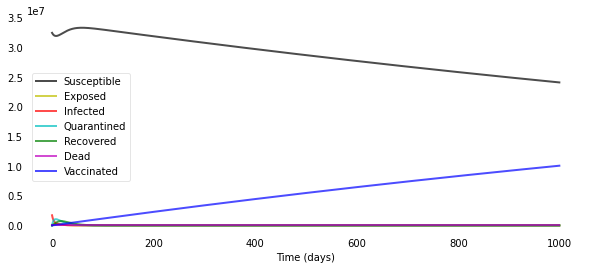

In [16]:
SEIQRDV_instance.plot_seiqrdv()

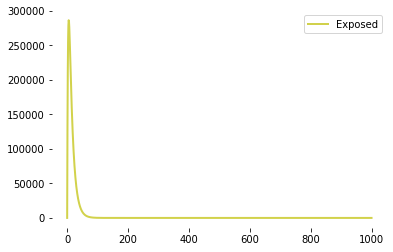

In [17]:
SEIQRDV_instance.plot_specific(SEIQRDV_instance.E, 'Exposed', 'y')

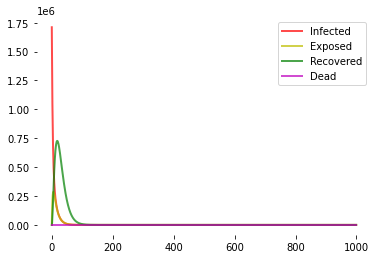

In [18]:
SEIQRDV_instance.plot_specific(SEIQRDV_instance.I, 'Infected', 'r')
SEIQRDV_instance.plot_specific(SEIQRDV_instance.E, 'Exposed', 'y')
SEIQRDV_instance.plot_specific(SEIQRDV_instance.R, 'Recovered', 'g')
SEIQRDV_instance.plot_specific(SEIQRDV_instance.D, 'Dead', 'm')

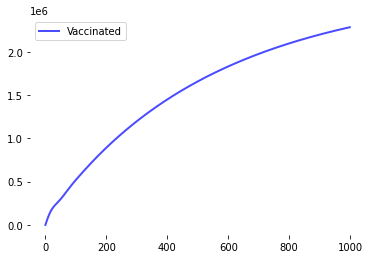

In [11]:
SEIQRDV_instance.plot_specific(SEIQRDV_instance.V, 'Vaccinated', 'b')

In [12]:
3.1 * 10**-5

3.1e-05

In [13]:
MAX_NUM_OF_PEOPLE = 34218000
no_of_episodes = 12
capital_lambda = 0
beta = 0.3
alpha = 3.5 * 10**-4
mu = 0
gamma = 1/5.5
sigma = 0.05
delta = 1/3.8
kappa = 0
nu = 1/10
rho = 1/15
omega = 1/10
alpha_threshold = 0.05

class SEIQRDV_Env(Env):
    def __init__(self):
        # Actions we can take: increse alpha, decrease alpha, don't change alpha
        self.action_space = Discrete(3)
        
        # Observation space: percentage of population infected
        self.observation_space = Box(low = 0, high = 1, shape=(1,), dtype=np.float16)
        
        # an initial alpha value
        # changes with policy
        self.state = alpha
        
        # number of people in each compartment
        # initial values
        self.t = np.arange(0, 30, 1)
        self.S = MAX_NUM_OF_PEOPLE * 0.95
        self.E = 0
        self.I = MAX_NUM_OF_PEOPLE * 0.05
        self.Q = 0
        self.R = 0
        self.D = 0
        self.V = MAX_NUM_OF_PEOPLE * 0
        
        # creating histories for plots
        self.S_history = [self.S]
        self.E_history = [self.E]
        self.I_history = [self.I]
        self.Q_history = [self.Q]
        self.R_history = [self.R]
        self.D_history = [self.D]
        self.V_history = [self.V]
        
        self.alpha_history = [self.state]
        
        
        self.capital_lambda = capital_lambda
        self.beta = beta
        self.mu = mu
        self.gamma = gamma
        self.sigma = sigma
        self.delta = delta
        self.kappa = kappa
        self.nu = nu
        self.rho = rho
        self.omega = omega
        
        # episode length 1 year = 12 months
        self.episode_length = no_of_episodes
        self.episode_length_fixed = no_of_episodes
        self.episode_plot = list(range(1, self.episode_length_fixed + 1))
        
    def step(self, action):
        reward = 0
        # print('SELF STATE NOW: ', self.state)
        if action == 0:
            if self.state > 0.01:
                # print('SUBTRACTED')
                self.state -= 0.01
            else:
                self.state = self.state
        elif action == 1:
            self.state += 0.01
        else:
            self.state = self.state
            
        # reduce episode length
        self.episode_length -= 1
        
        if (self.beta/self.gamma)*(self.S/MAX_NUM_OF_PEOPLE) <= 1:
            print('r_eff reward')
            reward += 1
        else:
            reward -= 1
            
        # economic cost: cost of increasing alpha
        if self.state >= alpha_threshold:
            reward -= 1
        else:
            print('alpha reward')
            reward += 1
        
        if self.episode_length <= 0:
            done = True
        else:
            done = False
        
        SEIQRDV_model_step = SEIQRDV_Model(t = self.t,
                        N = MAX_NUM_OF_PEOPLE, 
                        S0 = self.S,
                        E0 = self.E,
                        I0 = self.I,
                        Q0 = self.Q,
                        R0 = self.R,
                        V0 = self.V,
                        D0 = self.D,
                        capital_lambda = self.capital_lambda,
                        beta = self.beta,
                        alpha = self.state,
                        mu = self.mu,
                        gamma = self.gamma,
                        sigma = self.sigma, 
                        delta = self.delta,
                        kappa = self.kappa,
                        nu = self.nu,
                        rho = self.rho,
                        omega = self.omega
                       )
        
        
        # value updates for the next episode
        self.S = SEIQRDV_model_step.S[-1]
        self.E = SEIQRDV_model_step.E[-1]
        self.I = SEIQRDV_model_step.I[-1]
        self.Q = SEIQRDV_model_step.Q[-1]
        self.R = SEIQRDV_model_step.R[-1]
        self.D = SEIQRDV_model_step.D[-1]
        self.V = SEIQRDV_model_step.V[-1]
        
        self.S_history.append(self.S)
        self.E_history.append(self.E)
        self.I_history.append(self.I)
        self.Q_history.append(self.Q)
        self.R_history.append(self.R)
        self.D_history.append(self.D)
        self.V_history.append(self.V)
        self.alpha_history.append(self.state)
        
        # self.observation_space = np.array([self.I / MAX_NUM_OF_PEOPLE])
        
        # placeholder for info
        info = {}
        
        return self.state, reward, done, info
        
    def render(self, mode):
        # implement environment visualization
        print('alpha: {:.4f}, S: {}, E: {}, I: {}, Q: {}, R: {}, D: {}, V: {}'.format(self.state, 
                                                                                      int(self.S), int(self.E),
                                                                                      int(self.I), int(self.Q),
                                                                                      int(self.R), int(self.D),
                                                                                      int(self.V)
                                                                                     ))
        if len(self.S_history) == no_of_episodes:
            f, ax = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={'width_ratios': [3, 2]})
            f.subplots_adjust(hspace=0.8, wspace=0.4)
            ax[0].plot(self.episode_plot, self.V_history, 'b', alpha=0.7, linewidth=2, label='Vaccinated')
            ax[0].plot(self.episode_plot, self.S_history, 'k', alpha=0.7, linewidth=2, label='Susceptible')
            ax[0].plot(self.episode_plot, self.I_history, 'r', alpha=0.7, linewidth=2, label='Infected')
            ax[0].plot(self.episode_plot, self.E_history, 'y', alpha=0.7, linewidth=2, label='Exposed')
            ax[0].plot(self.episode_plot, self.R_history, 'g', alpha=0.7, linewidth=2, label='Recovered')
            ax[0].plot([], [], ' ', label="α threshold: " + str(alpha_threshold))
            ax[0].plot([], [], ' ', label="β: " + str(beta))

            ax[0].set_xlabel('Time (months)')

            ax[0].yaxis.set_tick_params(length=0)
            ax[0].xaxis.set_tick_params(length=0)
            ax[0].grid(b=True, which='major', c='w', lw=2, ls='-')
            legend = ax[0].legend(loc='upper right')
            legend.get_frame().set_alpha(0.5)
            for spine in ('top', 'right', 'bottom', 'left'):
                ax[0].spines[spine].set_visible(False)
            
            ax[1].plot(self.episode_plot, self.alpha_history, 'k')
            ax[1].set_title('alpha history')
            ax[1].set_xlabel('Time (months)')
            ax[1].set_ylabel('alpha')
            # plt.savefig('output_pics/changing_beta/alpha_' + str(alpha_threshold) + 'beta_' + str(beta) + '.png')
            plt.show()
    
    def reset(self):
        self.state = alpha
        
        self.t = np.arange(0, 30, 1)
        self.S = MAX_NUM_OF_PEOPLE * 0.95
        self.E = 0
        self.I = MAX_NUM_OF_PEOPLE * 0.05
        self.Q = 0
        self.R = 0
        self.D = 0
        self.V = MAX_NUM_OF_PEOPLE * 0
        
        self.capital_lambda = capital_lambda
        self.beta = beta
        self.mu = mu
        self.gamma = gamma
        self.sigma = sigma
        self.delta = delta
        self.kappa = kappa
        self.nu = nu
        self.rho = rho
        self.omega = omega
        
        self.S_history = [self.S]
        self.E_history = [self.E]
        self.I_history = [self.I]
        self.Q_history = [self.Q]
        self.R_history = [self.R]
        self.D_history = [self.D]
        self.V_history = [self.V]
        
        self.alpha_history = [self.state]
        
        self.episode_length = no_of_episodes
        return self.state

In [14]:
env = SEIQRDV_Env()

alpha: 0.0003, S: 32507100, E: 0, I: 1710900, Q: 0, R: 0, D: 0, V: 0
alpha reward
alpha: 0.0003, S: 28731990, E: 1010287, I: 709615, Q: 1845694, R: 1618613, D: 0, V: 301798
alpha reward
alpha: 0.0103, S: 22288270, E: 585930, I: 450114, Q: 1452030, R: 1628396, D: 0, V: 7813257
alpha reward
alpha: 0.0103, S: 18403815, E: 201729, I: 165788, Q: 666031, R: 920328, D: 0, V: 13860306
r_eff reward
alpha reward
alpha: 0.0003, S: 19497855, E: 62708, I: 50810, Q: 220062, R: 349967, D: 0, V: 14036595
r_eff reward
alpha reward
alpha: 0.0003, S: 19761118, E: 21051, I: 16950, Q: 71870, R: 116262, D: 0, V: 14230746
r_eff reward
alpha reward
alpha: 0.0103, S: 14771548, E: 4999, I: 4405, Q: 21874, R: 37496, D: 0, V: 19377676
r_eff reward
alpha reward
alpha: 0.0204, S: 8225904, E: 507, I: 529, Q: 4241, R: 9409, D: 0, V: 25977407
r_eff reward
alpha reward
alpha: 0.0103, S: 6103486, E: 27, I: 31, Q: 472, R: 1537, D: 0, V: 28112445
r_eff reward
alpha reward
alpha: 0.0003, S: 6043689, E: 1, I: 1, Q: 38, R: 1

/tmp/ipykernel_609/2447136139.py:173: MatplotlibDeprecationWarning: The 'b' parameter of grid() has been renamed 'visible' since Matplotlib 3.5; support for the old name will be dropped two minor releases later.
  ax[0].grid(b=True, which='major', c='w', lw=2, ls='-')


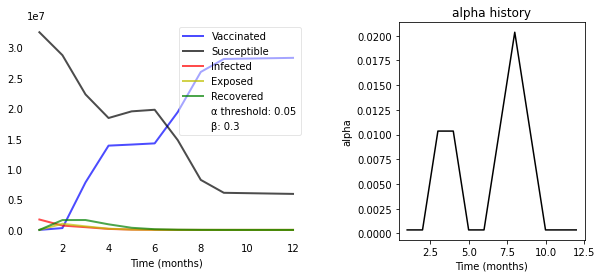

r_eff reward
alpha reward
Episode: 1 and Score: 18
alpha: 0.0003, S: 32507100, E: 0, I: 1710900, Q: 0, R: 0, D: 0, V: 0
alpha reward
alpha: 0.0103, S: 22201318, E: 662965, I: 509263, Q: 1544081, R: 1467909, D: 0, V: 7832460
alpha reward
alpha: 0.0003, S: 23742931, E: 320687, I: 242406, Q: 833693, R: 1048397, D: 0, V: 8029883
alpha reward
alpha: 0.0003, S: 24643271, E: 180359, I: 134165, Q: 442016, R: 560797, D: 0, V: 8257389
alpha reward
alpha: 0.0003, S: 24961072, E: 107967, I: 79850, Q: 255899, R: 314854, D: 0, V: 8498356
alpha reward
alpha: 0.0003, S: 25016819, E: 65852, I: 48638, Q: 154432, R: 187003, D: 0, V: 8745252
alpha reward
alpha: 0.0103, S: 18722493, E: 26843, I: 21818, Q: 81987, R: 107396, D: 0, V: 15257459
r_eff reward
alpha reward
alpha: 0.0103, S: 14004494, E: 5667, I: 5083, Q: 26077, R: 43134, D: 0, V: 20133543
r_eff reward
alpha reward
alpha: 0.0103, S: 10426206, E: 684, I: 673, Q: 5005, R: 10976, D: 0, V: 23774454
r_eff reward
alpha reward
alpha: 0.0003, S: 10335546,

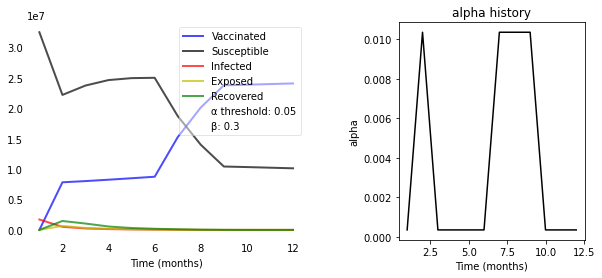

r_eff reward
alpha reward
Episode: 2 and Score: 12
alpha: 0.0003, S: 32507100, E: 0, I: 1710900, Q: 0, R: 0, D: 0, V: 0
alpha reward
alpha: 0.0103, S: 22201318, E: 662965, I: 509263, Q: 1544081, R: 1467909, D: 0, V: 7832460
alpha reward
alpha: 0.0003, S: 23742931, E: 320687, I: 242406, Q: 833693, R: 1048397, D: 0, V: 8029883
alpha reward
alpha: 0.0103, S: 18719695, E: 122623, I: 99926, Q: 388406, R: 533370, D: 0, V: 14353976
r_eff reward
alpha reward
alpha: 0.0204, S: 10964998, E: 19870, I: 19104, Q: 111976, R: 197008, D: 0, V: 22905042
r_eff reward
alpha reward
alpha: 0.0204, S: 6280595, E: 1313, I: 1475, Q: 16362, R: 42695, D: 0, V: 27875556
r_eff reward
alpha reward
alpha: 0.0304, S: 2636332, E: 39, I: 52, Q: 1437, R: 5793, D: 0, V: 31574344
r_eff reward
alpha reward
alpha: 0.0304, S: 1097112, E: 0, I: 1, Q: 93, R: 572, D: 0, V: 33120219
r_eff reward
alpha reward
alpha: 0.0404, S: 340744, E: 0, I: 0, Q: 5, R: 46, D: 0, V: 33877203
r_eff reward
alpha reward
alpha: 0.0404, S: 105762, 

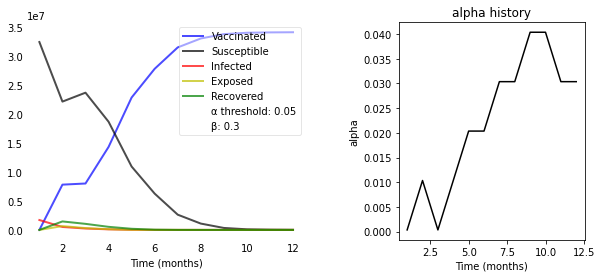

r_eff reward
alpha reward
Episode: 3 and Score: 18
alpha: 0.0003, S: 32507100, E: 0, I: 1710900, Q: 0, R: 0, D: 0, V: 0
alpha reward
alpha: 0.0003, S: 28731990, E: 1010287, I: 709615, Q: 1845694, R: 1618613, D: 0, V: 301798
alpha reward
alpha: 0.0103, S: 22288270, E: 585930, I: 450114, Q: 1452030, R: 1628396, D: 0, V: 7813257
alpha reward
alpha: 0.0103, S: 18403815, E: 201729, I: 165788, Q: 666031, R: 920328, D: 0, V: 13860306
r_eff reward
alpha reward
alpha: 0.0103, S: 14773522, E: 44631, I: 39433, Q: 200508, R: 339269, D: 0, V: 18820634
r_eff reward
alpha reward
alpha: 0.0204, S: 8540404, E: 4692, I: 4853, Q: 38442, R: 85291, D: 0, V: 25544315
r_eff reward
alpha reward
alpha: 0.0103, S: 6421077, E: 270, I: 304, Q: 4367, R: 14024, D: 0, V: 27777955
r_eff reward
alpha reward
alpha: 0.0103, S: 4770085, E: 11, I: 13, Q: 358, R: 1645, D: 0, V: 29445886
r_eff reward
alpha reward
alpha: 0.0103, S: 3534748, E: 0, I: 0, Q: 24, R: 154, D: 0, V: 30683071
r_eff reward
alpha reward
alpha: 0.0204,

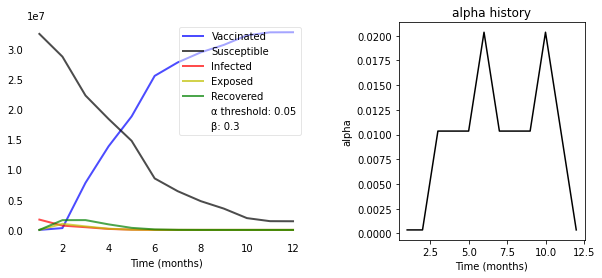

r_eff reward
alpha reward
Episode: 4 and Score: 18
alpha: 0.0003, S: 32507100, E: 0, I: 1710900, Q: 0, R: 0, D: 0, V: 0
alpha reward
alpha: 0.0003, S: 28731990, E: 1010287, I: 709615, Q: 1845694, R: 1618613, D: 0, V: 301798
alpha reward
alpha: 0.0003, S: 28693099, E: 874734, I: 615507, Q: 1697215, R: 1748779, D: 0, V: 588664
alpha reward
alpha: 0.0003, S: 28967353, E: 777344, I: 544728, Q: 1493634, R: 1558929, D: 0, V: 876008
alpha reward
alpha: 0.0003, S: 29113608, E: 707145, I: 494350, Q: 1344919, R: 1393804, D: 0, V: 1164171
alpha reward
alpha: 0.0003, S: 29161863, E: 650181, I: 454094, Q: 1230722, R: 1269025, D: 0, V: 1452113
alpha reward
alpha: 0.0003, S: 29159703, E: 599800, I: 418819, Q: 1133742, R: 1166645, D: 0, V: 1739287
alpha reward
alpha: 0.0003, S: 29131483, E: 553111, I: 386284, Q: 1045798, R: 1075810, D: 0, V: 2025511
alpha reward
alpha: 0.0103, S: 22251586, E: 334799, I: 256613, Q: 818640, R: 921262, D: 0, V: 9635098
alpha reward
alpha: 0.0103, S: 17569943, E: 109146, 

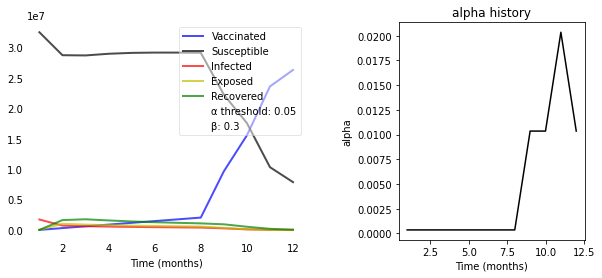

r_eff reward
alpha reward
Episode: 5 and Score: 6
alpha: 0.0003, S: 32507100, E: 0, I: 1710900, Q: 0, R: 0, D: 0, V: 0
alpha reward
alpha: 0.0003, S: 28731990, E: 1010287, I: 709615, Q: 1845694, R: 1618613, D: 0, V: 301798
alpha reward
alpha: 0.0003, S: 28693099, E: 874734, I: 615507, Q: 1697215, R: 1748779, D: 0, V: 588664
alpha reward
alpha: 0.0003, S: 28967353, E: 777344, I: 544728, Q: 1493634, R: 1558929, D: 0, V: 876008
alpha reward
alpha: 0.0003, S: 29113608, E: 707145, I: 494350, Q: 1344919, R: 1393804, D: 0, V: 1164171
alpha reward
alpha: 0.0003, S: 29161863, E: 650181, I: 454094, Q: 1230722, R: 1269025, D: 0, V: 1452113
alpha reward
alpha: 0.0003, S: 29159703, E: 599800, I: 418819, Q: 1133742, R: 1166645, D: 0, V: 1739287
alpha reward
alpha: 0.0103, S: 22324312, E: 364437, I: 279080, Q: 888992, R: 999636, D: 0, V: 9361540
alpha reward
alpha: 0.0204, S: 13493043, E: 86144, I: 77773, Q: 368987, R: 544881, D: 0, V: 19647170
r_eff reward
alpha reward
alpha: 0.0103, S: 10697510, E:

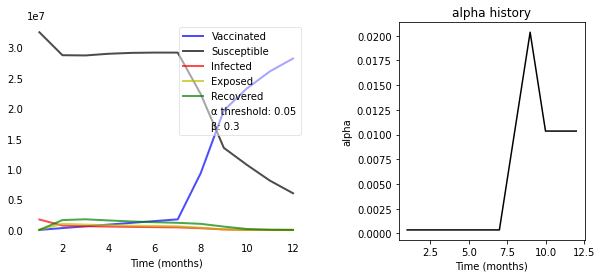

r_eff reward
alpha reward
Episode: 6 and Score: 8
alpha: 0.0003, S: 32507100, E: 0, I: 1710900, Q: 0, R: 0, D: 0, V: 0
alpha reward
alpha: 0.0103, S: 22201318, E: 662965, I: 509263, Q: 1544081, R: 1467909, D: 0, V: 7832460
alpha reward
alpha: 0.0003, S: 23742931, E: 320687, I: 242406, Q: 833693, R: 1048397, D: 0, V: 8029883
alpha reward
alpha: 0.0003, S: 24643271, E: 180359, I: 134165, Q: 442016, R: 560797, D: 0, V: 8257389
alpha reward
alpha: 0.0003, S: 24961072, E: 107967, I: 79850, Q: 255899, R: 314854, D: 0, V: 8498356
alpha reward
alpha: 0.0103, S: 18812160, E: 44122, I: 35816, Q: 134556, R: 176922, D: 0, V: 15014421
r_eff reward
alpha reward
alpha: 0.0103, S: 14158365, E: 9472, I: 8468, Q: 43095, R: 71042, D: 0, V: 19927555
r_eff reward
alpha reward
alpha: 0.0204, S: 7922118, E: 901, I: 950, Q: 7975, R: 17986, D: 0, V: 26268067
r_eff reward
alpha reward
alpha: 0.0204, S: 4407531, E: 39, I: 47, Q: 842, R: 2856, D: 0, V: 29806682
r_eff reward
alpha reward
alpha: 0.0103, S: 3267488,

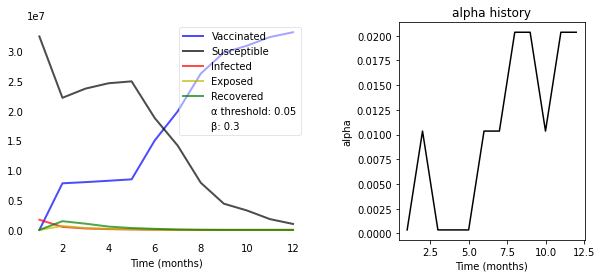

r_eff reward
alpha reward
Episode: 7 and Score: 14
alpha: 0.0003, S: 32507100, E: 0, I: 1710900, Q: 0, R: 0, D: 0, V: 0
alpha reward
alpha: 0.0103, S: 22201318, E: 662965, I: 509263, Q: 1544081, R: 1467909, D: 0, V: 7832460
alpha reward
alpha: 0.0204, S: 14070122, E: 160340, I: 143269, Q: 668063, R: 959646, D: 0, V: 18216557
r_eff reward
alpha reward
alpha: 0.0103, S: 11664240, E: 21797, I: 20799, Q: 141282, R: 287109, D: 0, V: 22082770
r_eff reward
alpha reward
alpha: 0.0204, S: 6742383, E: 1592, I: 1756, Q: 19403, R: 54036, D: 0, V: 27398828
r_eff reward
alpha reward
alpha: 0.0204, S: 3783675, E: 58, I: 73, Q: 1747, R: 7099, D: 0, V: 30425344
r_eff reward
alpha reward
alpha: 0.0103, S: 2809276, E: 1, I: 2, Q: 118, R: 706, D: 0, V: 31407895
r_eff reward
alpha reward
alpha: 0.0103, S: 2081473, E: 0, I: 0, Q: 7, R: 58, D: 0, V: 32136460
r_eff reward
alpha reward
alpha: 0.0204, S: 1153685, E: 0, I: 0, Q: 0, R: 4, D: 0, V: 33064309
r_eff reward
alpha reward
alpha: 0.0304, S: 478459, E: 0,

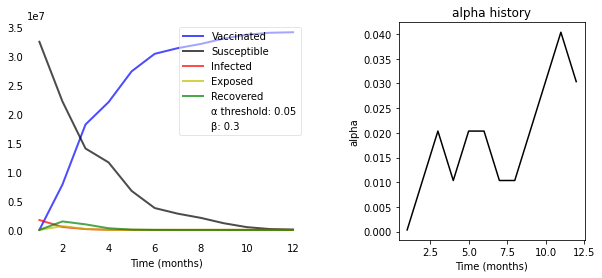

r_eff reward
alpha reward
Episode: 8 and Score: 20
alpha: 0.0003, S: 32507100, E: 0, I: 1710900, Q: 0, R: 0, D: 0, V: 0
alpha reward
alpha: 0.0003, S: 28731990, E: 1010287, I: 709615, Q: 1845694, R: 1618613, D: 0, V: 301798
alpha reward
alpha: 0.0003, S: 28693099, E: 874734, I: 615507, Q: 1697215, R: 1748779, D: 0, V: 588664
alpha reward
alpha: 0.0003, S: 28967353, E: 777344, I: 544728, Q: 1493634, R: 1558929, D: 0, V: 876008
alpha reward
alpha: 0.0103, S: 22460851, E: 469201, I: 358930, Q: 1146229, R: 1297029, D: 0, V: 8485756
alpha reward
alpha: 0.0204, S: 13884648, E: 114825, I: 102834, Q: 480537, R: 705600, D: 0, V: 18929552
r_eff reward
alpha reward
alpha: 0.0103, S: 11193284, E: 14789, I: 14281, Q: 99882, R: 206022, D: 0, V: 22689739
r_eff reward
alpha reward
alpha: 0.0103, S: 8525442, E: 1266, I: 1323, Q: 13644, R: 38081, D: 0, V: 25638242
r_eff reward
alpha reward
alpha: 0.0003, S: 8486766, E: 89, I: 95, Q: 1389, R: 5157, D: 0, V: 25724501
r_eff reward
alpha reward
alpha: 0.010

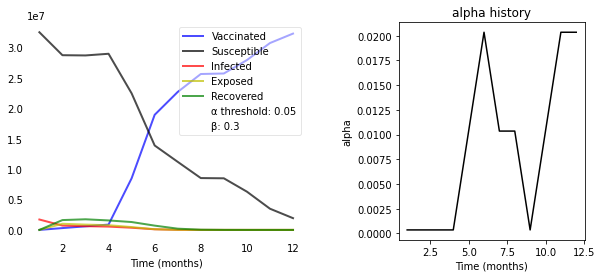

r_eff reward
alpha reward
Episode: 9 and Score: 14
alpha: 0.0003, S: 32507100, E: 0, I: 1710900, Q: 0, R: 0, D: 0, V: 0
alpha reward
alpha: 0.0003, S: 28731990, E: 1010287, I: 709615, Q: 1845694, R: 1618613, D: 0, V: 301798
alpha reward
alpha: 0.0003, S: 28693099, E: 874734, I: 615507, Q: 1697215, R: 1748779, D: 0, V: 588664
alpha reward
alpha: 0.0003, S: 28967353, E: 777344, I: 544728, Q: 1493634, R: 1558929, D: 0, V: 876008
alpha reward
alpha: 0.0003, S: 29113608, E: 707145, I: 494350, Q: 1344919, R: 1393804, D: 0, V: 1164171
alpha reward
alpha: 0.0003, S: 29161863, E: 650181, I: 454094, Q: 1230722, R: 1269025, D: 0, V: 1452113
alpha reward
alpha: 0.0003, S: 29159703, E: 599800, I: 418819, Q: 1133742, R: 1166645, D: 0, V: 1739287
alpha reward
alpha: 0.0003, S: 29131483, E: 553111, I: 386284, Q: 1045798, R: 1075810, D: 0, V: 2025511
alpha reward
alpha: 0.0103, S: 22251586, E: 334799, I: 256613, Q: 818640, R: 921262, D: 0, V: 9635098
alpha reward
alpha: 0.0003, S: 23128573, E: 158406, 

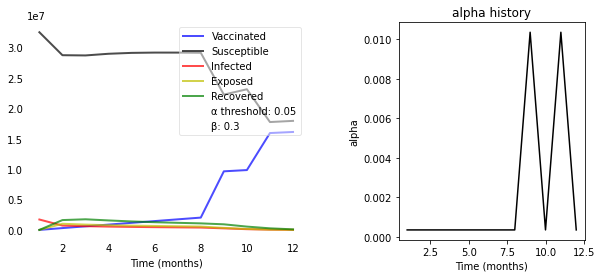

r_eff reward
alpha reward
Episode: 10 and Score: 4
alpha: 0.0003, S: 32507100, E: 0, I: 1710900, Q: 0, R: 0, D: 0, V: 0
alpha reward
alpha: 0.0103, S: 22201318, E: 662965, I: 509263, Q: 1544081, R: 1467909, D: 0, V: 7832460
alpha reward
alpha: 0.0103, S: 18255351, E: 222603, I: 183555, Q: 739544, R: 999388, D: 0, V: 13817555
r_eff reward
alpha reward
alpha: 0.0204, S: 11229992, E: 36123, I: 34542, Q: 204145, R: 364002, D: 0, V: 22349193
r_eff reward
alpha reward
alpha: 0.0103, S: 8757019, E: 3167, I: 3286, Q: 31211, R: 78986, D: 0, V: 25344329
r_eff reward
alpha reward
alpha: 0.0204, S: 4923996, E: 155, I: 185, Q: 3195, R: 11461, D: 0, V: 29279005
r_eff reward
alpha reward
alpha: 0.0304, S: 2049791, E: 3, I: 5, Q: 236, R: 1237, D: 0, V: 32166724
r_eff reward
alpha reward
alpha: 0.0304, S: 850855, E: 0, I: 0, Q: 14, R: 108, D: 0, V: 33367021
r_eff reward
alpha reward
alpha: 0.0204, S: 471658, E: 0, I: 0, Q: 0, R: 8, D: 0, V: 33746332
r_eff reward
alpha reward
alpha: 0.0204, S: 261419, E

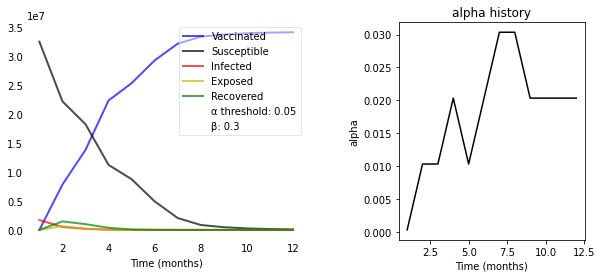

r_eff reward
alpha reward
Episode: 11 and Score: 20
alpha: 0.0003, S: 32507100, E: 0, I: 1710900, Q: 0, R: 0, D: 0, V: 0
alpha reward
alpha: 0.0103, S: 22201318, E: 662965, I: 509263, Q: 1544081, R: 1467909, D: 0, V: 7832460
alpha reward
alpha: 0.0204, S: 14070122, E: 160340, I: 143269, Q: 668063, R: 959646, D: 0, V: 18216557
r_eff reward
alpha reward
alpha: 0.0304, S: 6767529, E: 13298, I: 14561, Q: 127873, R: 278668, D: 0, V: 27016068
r_eff reward
alpha reward
alpha: 0.0304, S: 3027909, E: 439, I: 573, Q: 12586, R: 44228, D: 0, V: 31132261
r_eff reward
alpha reward
alpha: 0.0204, S: 1713814, E: 8, I: 12, Q: 855, R: 4713, D: 0, V: 32498593
r_eff reward
alpha reward
alpha: 0.0204, S: 953339, E: 0, I: 0, Q: 50, R: 401, D: 0, V: 33264208
r_eff reward
alpha reward
alpha: 0.0204, S: 528664, E: 0, I: 0, Q: 2, R: 30, D: 0, V: 33689302
r_eff reward
alpha reward
alpha: 0.0103, S: 391610, E: 0, I: 0, Q: 0, R: 2, D: 0, V: 33826387
r_eff reward
alpha reward
alpha: 0.0003, S: 387657, E: 0, I: 0, Q

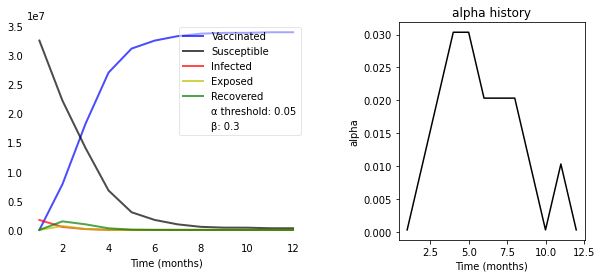

r_eff reward
alpha reward
Episode: 12 and Score: 20


In [15]:
episodes = no_of_episodes
for episode in range(1, episodes+1):
    state = env.reset()
    done = False
    score = 0
    
    while not done:
        env.render(mode='human')
        action = env.action_space.sample()
        # action = 1
        n_state, reward, done, info = env.step(action)
        score += reward
    print('Episode: {} and Score: {}'.format(episode, score))

## Create a Deep Learning Model with Keras

In [16]:
states = env.observation_space.shape
actions = env.action_space.n
print(states, actions)

(1,) 3


In [17]:
def build_model(states, actions):
    model = Sequential()    
    model.add(Dense(64, activation='relu', input_shape=states))
    model.add(Dense(48, activation='relu'))
    model.add(Dense(24, activation='relu'))
    model.add(Dense(actions, activation='linear'))
    return model

In [18]:
model = build_model(states, actions)
del model
model = build_model(states, actions)
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 64)                128       
                                                                 
 dense_5 (Dense)             (None, 48)                3120      
                                                                 
 dense_6 (Dense)             (None, 24)                1176      
                                                                 
 dense_7 (Dense)             (None, 3)                 75        
                                                                 
Total params: 4,499
Trainable params: 4,499
Non-trainable params: 0
_________________________________________________________________


In [19]:
def build_agent(model, actions):
    policy = EpsGreedyQPolicy()
    memory = SequentialMemory(limit=500, window_length=1)
    dqn = DQNAgent(model=model, memory=memory, policy=policy, 
                  nb_actions=actions, nb_steps_warmup=10, target_model_update=1e-2)
    return dqn

In [20]:
dqn = build_agent(model, actions)
dqn.compile(Adam(lr=1e-3))
dqn.fit(env, nb_steps=10000, visualize=False, verbose=1)

/home/vanilla_skies/.local/lib/python3.8/site-packages/keras/optimizer_v2/adam.py:105: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super(Adam, self).__init__(name, **kwargs)
2022-06-09 13:32:00.025538: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:922] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2022-06-09 13:32:00.084456: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcusolver.so.11'; dlerror: libcusolver.so.11: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /home/vanilla_skies/.local/lib/python3.8/site-packages/cv2/../../lib64:
2022-06-09 13:32:00.092094: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1850] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at h

Training for 10000 steps ...
Interval 1 (0 steps performed)
alpha reward
    1/10000 [..............................] - ETA: 45:36 - reward: 0.0000e+00alpha reward
alpha reward
alpha reward
alpha reward
alpha reward
alpha reward
alpha reward
alpha reward
alpha reward
alpha reward
alpha reward


/home/vanilla_skies/.local/lib/python3.8/site-packages/keras/engine/training_v1.py:2079: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates=self.state_updates,
/home/vanilla_skies/.local/lib/python3.8/site-packages/rl/memory.py:37: UserWarning: Not enough entries to sample without replacement. Consider increasing your warm-up phase to avoid oversampling!
  warnings.warn('Not enough entries to sample without replacement. Consider increasing your warm-up phase to avoid oversampling!')
/home/vanilla_skies/.local/lib/python3.8/site-packages/rl/memory.py:38: DeprecationWarning: This function is deprecated. Please call randint(1, 10 + 1) instead
  batch_idxs = np.random.random_integers(low, high - 1, size=size)


   12/10000 [..............................] - ETA: 11:39 - reward: 0.0000e+00alpha reward
alpha reward
alpha reward
   15/10000 [..............................] - ETA: 9:45 - reward: 0.0000e+00 alpha reward
alpha reward
alpha reward
alpha reward
r_eff reward
alpha reward
   20/10000 [..............................] - ETA: 7:42 - reward: 0.1000    r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
   24/10000 [..............................] - ETA: 6:44 - reward: 0.4167alpha reward
alpha reward
alpha reward


/home/vanilla_skies/.local/lib/python3.8/site-packages/rl/memory.py:38: DeprecationWarning: This function is deprecated. Please call randint(1, 11 + 1) instead
  batch_idxs = np.random.random_integers(low, high - 1, size=size)
/home/vanilla_skies/.local/lib/python3.8/site-packages/rl/memory.py:38: DeprecationWarning: This function is deprecated. Please call randint(1, 12 + 1) instead
  batch_idxs = np.random.random_integers(low, high - 1, size=size)
/home/vanilla_skies/.local/lib/python3.8/site-packages/rl/memory.py:38: DeprecationWarning: This function is deprecated. Please call randint(1, 13 + 1) instead
  batch_idxs = np.random.random_integers(low, high - 1, size=size)
/home/vanilla_skies/.local/lib/python3.8/site-packages/rl/memory.py:38: DeprecationWarning: This function is deprecated. Please call randint(1, 14 + 1) instead
  batch_idxs = np.random.random_integers(low, high - 1, size=size)
/home/vanilla_skies/.local/lib/python3.8/site-packages/rl/memory.py:38: DeprecationWarning: 

...

 8519/10000 [========================>.....] - ETA: 18s - reward: 1.4767r_eff reward
alpha reward
alpha reward
alpha reward
r_eff reward
alpha reward
 8523/10000 [========================>.....] - ETA: 18s - reward: 1.4765r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
 8528/10000 [========================>.....] - ETA: 18s - reward: 1.4768r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
alpha reward
 8533/10000 [========================>.....] - ETA: 18s - reward: 1.4769alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
 8538/10000 [========================>.....] - ETA: 18s - reward: 1.4769r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
 8543/10000 [========================>.....] - ETA: 18s - reward: 1.

 8941/10000 [=========================>....] - ETA: 13s - reward: 1.4851alpha reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
 8946/10000 [=========================>....] - ETA: 13s - reward: 1.4849r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
 8951/10000 [=========================>....] - ETA: 13s - reward: 1.4852r_eff reward
alpha reward
alpha reward
alpha reward
r_eff reward
alpha reward
 8955/10000 [=========================>....] - ETA: 13s - reward: 1.4850r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
 8960/10000 [=========================>....] - ETA: 13s - reward: 1.4853r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
alpha reward
 8965/10000 [=========================>....] - ETA: 13s - reward: 1.4853alpha rew

r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
 9368/10000 [===========================>..] - ETA: 7s - reward: 1.4919r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
alpha reward
 9373/10000 [===========================>..] - ETA: 7s - reward: 1.4919alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
 9378/10000 [===========================>..] - ETA: 7s - reward: 1.4920r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
 9383/10000 [===========================>..] - ETA: 7s - reward: 1.4923r_eff reward
alpha reward
alpha reward
alpha reward
r_eff reward
alpha reward
 9387/10000 [===========================>..] - ETA: 7s - reward: 1.4921r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha re

 9579/10000 [===========================>..] - ETA: 5s - reward: 1.4947r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
 9584/10000 [===========================>..] - ETA: 5s - reward: 1.4950r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
alpha reward
 9589/10000 [===========================>..] - ETA: 5s - reward: 1.4950alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
 9594/10000 [===========================>..] - ETA: 5s - reward: 1.4951r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
 9599/10000 [===========================>..] - ETA: 5s - reward: 1.4954r_eff reward
alpha reward
alpha reward
alpha reward
r_eff reward
alpha reward
 9603/10000 [===========================>..] - ETA: 5s - reward: 1.4952r_

alpha reward
alpha reward
alpha reward
 9795/10000 [============================>.] - ETA: 2s - reward: 1.4969alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
 9800/10000 [============================>.] - ETA: 2s - reward: 1.4969r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
alpha reward
 9805/10000 [============================>.] - ETA: 2s - reward: 1.4970alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
 9810/10000 [============================>.] - ETA: 2s - reward: 1.4970r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
 9815/10000 [============================>.] - ETA: 2s - reward: 1.4973r_eff reward
alpha reward
alpha reward
alpha reward
alpha reward
 9819/10000 [============================>.] - ETA: 2s - rew

In [21]:
scores = dqn.test(env, nb_episodes=100, visualize=False)

Testing for 100 episodes ...
alpha reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
Episode 1: reward: 20.000, steps: 12
alpha reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
Episode 2: reward: 20.000, steps: 12
alpha reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
Episode 3: reward: 20.000, steps: 12
al

r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
Episode 26: reward: 20.000, steps: 12
alpha reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
Episode 27: reward: 20.000, steps: 12
alpha reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
Episode 28: reward: 20.000, steps: 12
alpha reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_

alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
Episode 53: reward: 20.000, steps: 12
alpha reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
Episode 54: reward: 20.000, steps: 12
alpha reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
Episode 55: reward: 20.000, steps: 12
alpha reward
alpha reward
r_eff reward
al

r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
Episode 78: reward: 20.000, steps: 12
alpha reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
Episode 79: reward: 20.000, steps: 12
alpha reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
Episode 80: reward: 20.000, steps: 12
alpha reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_eff reward
alpha reward
r_

In [22]:
print(np.mean(scores.history['episode_reward']))

20.0


Testing for 20 episodes ...
alpha reward
alpha: 0.0103, S: 22201318, E: 662965, I: 509263, Q: 1544081, R: 1467909, D: 0, V: 7832460
alpha reward
alpha: 0.0204, S: 14070122, E: 160340, I: 143269, Q: 668063, R: 959646, D: 0, V: 18216557
r_eff reward
alpha reward
alpha: 0.0103, S: 11664240, E: 21797, I: 20799, Q: 141282, R: 287109, D: 0, V: 22082770
r_eff reward
alpha reward
alpha: 0.0204, S: 6742383, E: 1592, I: 1756, Q: 19403, R: 54036, D: 0, V: 27398828
r_eff reward
alpha reward
alpha: 0.0103, S: 5050112, E: 68, I: 82, Q: 1769, R: 7114, D: 0, V: 29158851
r_eff reward
alpha reward
alpha: 0.0204, S: 2804564, E: 1, I: 2, Q: 125, R: 717, D: 0, V: 31412587
r_eff reward
alpha reward
alpha: 0.0103, S: 2077997, E: 0, I: 0, Q: 7, R: 60, D: 0, V: 32139934
r_eff reward
alpha reward
alpha: 0.0204, S: 1151760, E: 0, I: 0, Q: 0, R: 4, D: 0, V: 33066234
r_eff reward
alpha reward
alpha: 0.0103, S: 853120, E: 0, I: 0, Q: 0, R: 0, D: 0, V: 33364878
r_eff reward
alpha reward
alpha: 0.0204, S: 472837, E: 

/tmp/ipykernel_609/2447136139.py:173: MatplotlibDeprecationWarning: The 'b' parameter of grid() has been renamed 'visible' since Matplotlib 3.5; support for the old name will be dropped two minor releases later.
  ax[0].grid(b=True, which='major', c='w', lw=2, ls='-')


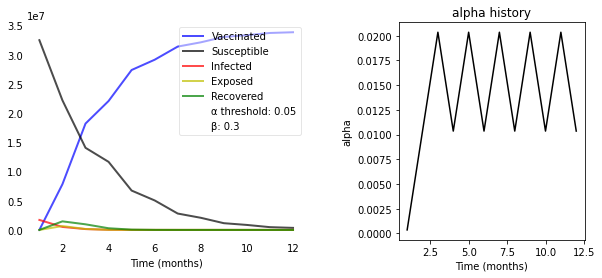

r_eff reward
alpha reward
alpha: 0.0204, S: 194115, E: 0, I: 0, Q: 0, R: 0, D: 0, V: 34023884
Episode 1: reward: 20.000, steps: 12
alpha reward
alpha: 0.0103, S: 22201318, E: 662965, I: 509263, Q: 1544081, R: 1467909, D: 0, V: 7832460
alpha reward
alpha: 0.0204, S: 14070122, E: 160340, I: 143269, Q: 668063, R: 959646, D: 0, V: 18216557
r_eff reward
alpha reward
alpha: 0.0103, S: 11664240, E: 21797, I: 20799, Q: 141282, R: 287109, D: 0, V: 22082770
r_eff reward
alpha reward
alpha: 0.0204, S: 6742383, E: 1592, I: 1756, Q: 19403, R: 54036, D: 0, V: 27398828
r_eff reward
alpha reward
alpha: 0.0103, S: 5050112, E: 68, I: 82, Q: 1769, R: 7114, D: 0, V: 29158851
r_eff reward
alpha reward
alpha: 0.0204, S: 2804564, E: 1, I: 2, Q: 125, R: 717, D: 0, V: 31412587
r_eff reward
alpha reward
alpha: 0.0103, S: 2077997, E: 0, I: 0, Q: 7, R: 60, D: 0, V: 32139934
r_eff reward
alpha reward
alpha: 0.0204, S: 1151760, E: 0, I: 0, Q: 0, R: 4, D: 0, V: 33066234
r_eff reward
alpha reward
alpha: 0.0103, S: 85

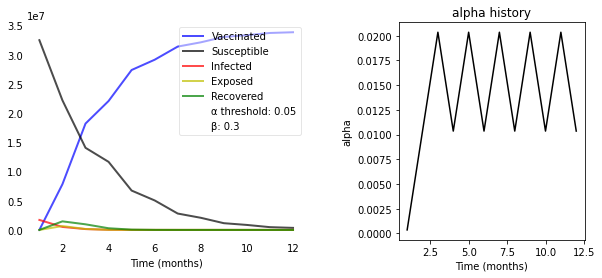

r_eff reward
alpha reward
alpha: 0.0204, S: 194115, E: 0, I: 0, Q: 0, R: 0, D: 0, V: 34023884
Episode 2: reward: 20.000, steps: 12
alpha reward
alpha: 0.0103, S: 22201318, E: 662965, I: 509263, Q: 1544081, R: 1467909, D: 0, V: 7832460
alpha reward
alpha: 0.0204, S: 14070122, E: 160340, I: 143269, Q: 668063, R: 959646, D: 0, V: 18216557
r_eff reward
alpha reward
alpha: 0.0103, S: 11664240, E: 21797, I: 20799, Q: 141282, R: 287109, D: 0, V: 22082770
r_eff reward
alpha reward
alpha: 0.0204, S: 6742383, E: 1592, I: 1756, Q: 19403, R: 54036, D: 0, V: 27398828
r_eff reward
alpha reward
alpha: 0.0103, S: 5050112, E: 68, I: 82, Q: 1769, R: 7114, D: 0, V: 29158851
r_eff reward
alpha reward
alpha: 0.0204, S: 2804564, E: 1, I: 2, Q: 125, R: 717, D: 0, V: 31412587
r_eff reward
alpha reward
alpha: 0.0103, S: 2077997, E: 0, I: 0, Q: 7, R: 60, D: 0, V: 32139934
r_eff reward
alpha reward
alpha: 0.0204, S: 1151760, E: 0, I: 0, Q: 0, R: 4, D: 0, V: 33066234
r_eff reward
alpha reward
alpha: 0.0103, S: 85

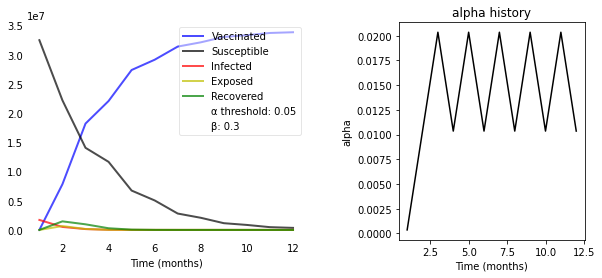

r_eff reward
alpha reward
alpha: 0.0204, S: 194115, E: 0, I: 0, Q: 0, R: 0, D: 0, V: 34023884
Episode 3: reward: 20.000, steps: 12
alpha reward
alpha: 0.0103, S: 22201318, E: 662965, I: 509263, Q: 1544081, R: 1467909, D: 0, V: 7832460
alpha reward
alpha: 0.0204, S: 14070122, E: 160340, I: 143269, Q: 668063, R: 959646, D: 0, V: 18216557
r_eff reward
alpha reward
alpha: 0.0103, S: 11664240, E: 21797, I: 20799, Q: 141282, R: 287109, D: 0, V: 22082770
r_eff reward
alpha reward
alpha: 0.0204, S: 6742383, E: 1592, I: 1756, Q: 19403, R: 54036, D: 0, V: 27398828
r_eff reward
alpha reward
alpha: 0.0103, S: 5050112, E: 68, I: 82, Q: 1769, R: 7114, D: 0, V: 29158851
r_eff reward
alpha reward
alpha: 0.0204, S: 2804564, E: 1, I: 2, Q: 125, R: 717, D: 0, V: 31412587
r_eff reward
alpha reward
alpha: 0.0103, S: 2077997, E: 0, I: 0, Q: 7, R: 60, D: 0, V: 32139934
r_eff reward
alpha reward
alpha: 0.0204, S: 1151760, E: 0, I: 0, Q: 0, R: 4, D: 0, V: 33066234
r_eff reward
alpha reward
alpha: 0.0103, S: 85

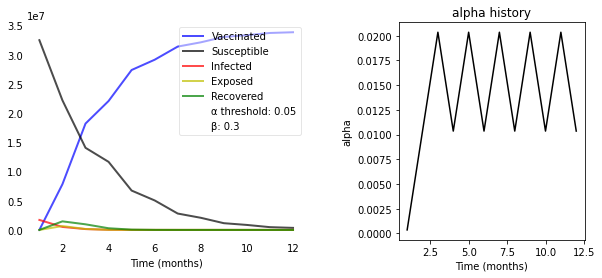

r_eff reward
alpha reward
alpha: 0.0204, S: 194115, E: 0, I: 0, Q: 0, R: 0, D: 0, V: 34023884
Episode 4: reward: 20.000, steps: 12
alpha reward
alpha: 0.0103, S: 22201318, E: 662965, I: 509263, Q: 1544081, R: 1467909, D: 0, V: 7832460
alpha reward
alpha: 0.0204, S: 14070122, E: 160340, I: 143269, Q: 668063, R: 959646, D: 0, V: 18216557
r_eff reward
alpha reward
alpha: 0.0103, S: 11664240, E: 21797, I: 20799, Q: 141282, R: 287109, D: 0, V: 22082770
r_eff reward
alpha reward
alpha: 0.0204, S: 6742383, E: 1592, I: 1756, Q: 19403, R: 54036, D: 0, V: 27398828
r_eff reward
alpha reward
alpha: 0.0103, S: 5050112, E: 68, I: 82, Q: 1769, R: 7114, D: 0, V: 29158851
r_eff reward
alpha reward
alpha: 0.0204, S: 2804564, E: 1, I: 2, Q: 125, R: 717, D: 0, V: 31412587
r_eff reward
alpha reward
alpha: 0.0103, S: 2077997, E: 0, I: 0, Q: 7, R: 60, D: 0, V: 32139934
r_eff reward
alpha reward
alpha: 0.0204, S: 1151760, E: 0, I: 0, Q: 0, R: 4, D: 0, V: 33066234
r_eff reward
alpha reward
alpha: 0.0103, S: 85

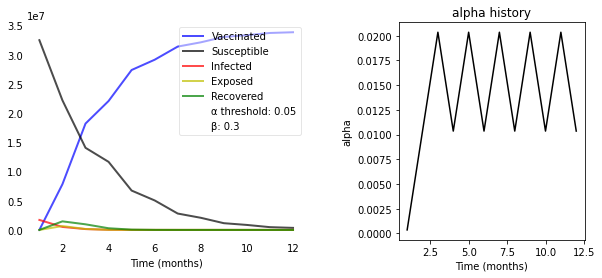

r_eff reward
alpha reward
alpha: 0.0204, S: 194115, E: 0, I: 0, Q: 0, R: 0, D: 0, V: 34023884
Episode 5: reward: 20.000, steps: 12
alpha reward
alpha: 0.0103, S: 22201318, E: 662965, I: 509263, Q: 1544081, R: 1467909, D: 0, V: 7832460
alpha reward
alpha: 0.0204, S: 14070122, E: 160340, I: 143269, Q: 668063, R: 959646, D: 0, V: 18216557
r_eff reward
alpha reward
alpha: 0.0103, S: 11664240, E: 21797, I: 20799, Q: 141282, R: 287109, D: 0, V: 22082770
r_eff reward
alpha reward
alpha: 0.0204, S: 6742383, E: 1592, I: 1756, Q: 19403, R: 54036, D: 0, V: 27398828
r_eff reward
alpha reward
alpha: 0.0103, S: 5050112, E: 68, I: 82, Q: 1769, R: 7114, D: 0, V: 29158851
r_eff reward
alpha reward
alpha: 0.0204, S: 2804564, E: 1, I: 2, Q: 125, R: 717, D: 0, V: 31412587
r_eff reward
alpha reward
alpha: 0.0103, S: 2077997, E: 0, I: 0, Q: 7, R: 60, D: 0, V: 32139934
r_eff reward
alpha reward
alpha: 0.0204, S: 1151760, E: 0, I: 0, Q: 0, R: 4, D: 0, V: 33066234
r_eff reward
alpha reward
alpha: 0.0103, S: 85

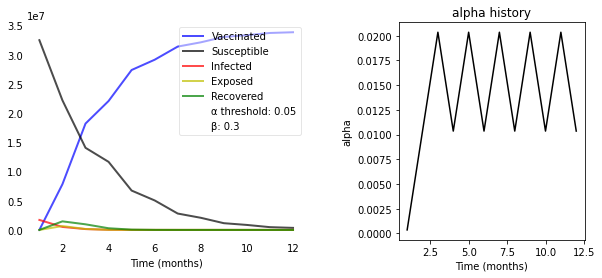

r_eff reward
alpha reward
alpha: 0.0204, S: 194115, E: 0, I: 0, Q: 0, R: 0, D: 0, V: 34023884
Episode 6: reward: 20.000, steps: 12
alpha reward
alpha: 0.0103, S: 22201318, E: 662965, I: 509263, Q: 1544081, R: 1467909, D: 0, V: 7832460
alpha reward
alpha: 0.0204, S: 14070122, E: 160340, I: 143269, Q: 668063, R: 959646, D: 0, V: 18216557
r_eff reward
alpha reward
alpha: 0.0103, S: 11664240, E: 21797, I: 20799, Q: 141282, R: 287109, D: 0, V: 22082770
r_eff reward
alpha reward
alpha: 0.0204, S: 6742383, E: 1592, I: 1756, Q: 19403, R: 54036, D: 0, V: 27398828
r_eff reward
alpha reward
alpha: 0.0103, S: 5050112, E: 68, I: 82, Q: 1769, R: 7114, D: 0, V: 29158851
r_eff reward
alpha reward
alpha: 0.0204, S: 2804564, E: 1, I: 2, Q: 125, R: 717, D: 0, V: 31412587
r_eff reward
alpha reward
alpha: 0.0103, S: 2077997, E: 0, I: 0, Q: 7, R: 60, D: 0, V: 32139934
r_eff reward
alpha reward
alpha: 0.0204, S: 1151760, E: 0, I: 0, Q: 0, R: 4, D: 0, V: 33066234
r_eff reward
alpha reward
alpha: 0.0103, S: 85

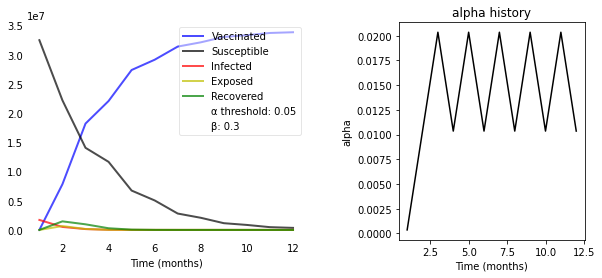

r_eff reward
alpha reward
alpha: 0.0204, S: 194115, E: 0, I: 0, Q: 0, R: 0, D: 0, V: 34023884
Episode 7: reward: 20.000, steps: 12
alpha reward
alpha: 0.0103, S: 22201318, E: 662965, I: 509263, Q: 1544081, R: 1467909, D: 0, V: 7832460
alpha reward
alpha: 0.0204, S: 14070122, E: 160340, I: 143269, Q: 668063, R: 959646, D: 0, V: 18216557
r_eff reward
alpha reward
alpha: 0.0103, S: 11664240, E: 21797, I: 20799, Q: 141282, R: 287109, D: 0, V: 22082770
r_eff reward
alpha reward
alpha: 0.0204, S: 6742383, E: 1592, I: 1756, Q: 19403, R: 54036, D: 0, V: 27398828
r_eff reward
alpha reward
alpha: 0.0103, S: 5050112, E: 68, I: 82, Q: 1769, R: 7114, D: 0, V: 29158851
r_eff reward
alpha reward
alpha: 0.0204, S: 2804564, E: 1, I: 2, Q: 125, R: 717, D: 0, V: 31412587
r_eff reward
alpha reward
alpha: 0.0103, S: 2077997, E: 0, I: 0, Q: 7, R: 60, D: 0, V: 32139934
r_eff reward
alpha reward
alpha: 0.0204, S: 1151760, E: 0, I: 0, Q: 0, R: 4, D: 0, V: 33066234
r_eff reward
alpha reward
alpha: 0.0103, S: 85

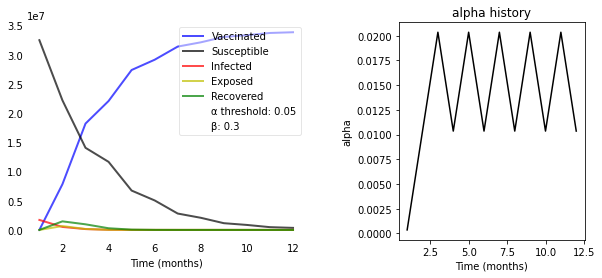

r_eff reward
alpha reward
alpha: 0.0204, S: 194115, E: 0, I: 0, Q: 0, R: 0, D: 0, V: 34023884
Episode 8: reward: 20.000, steps: 12
alpha reward
alpha: 0.0103, S: 22201318, E: 662965, I: 509263, Q: 1544081, R: 1467909, D: 0, V: 7832460
alpha reward
alpha: 0.0204, S: 14070122, E: 160340, I: 143269, Q: 668063, R: 959646, D: 0, V: 18216557
r_eff reward
alpha reward
alpha: 0.0103, S: 11664240, E: 21797, I: 20799, Q: 141282, R: 287109, D: 0, V: 22082770
r_eff reward
alpha reward
alpha: 0.0204, S: 6742383, E: 1592, I: 1756, Q: 19403, R: 54036, D: 0, V: 27398828
r_eff reward
alpha reward
alpha: 0.0103, S: 5050112, E: 68, I: 82, Q: 1769, R: 7114, D: 0, V: 29158851
r_eff reward
alpha reward
alpha: 0.0204, S: 2804564, E: 1, I: 2, Q: 125, R: 717, D: 0, V: 31412587
r_eff reward
alpha reward
alpha: 0.0103, S: 2077997, E: 0, I: 0, Q: 7, R: 60, D: 0, V: 32139934
r_eff reward
alpha reward
alpha: 0.0204, S: 1151760, E: 0, I: 0, Q: 0, R: 4, D: 0, V: 33066234
r_eff reward
alpha reward
alpha: 0.0103, S: 85

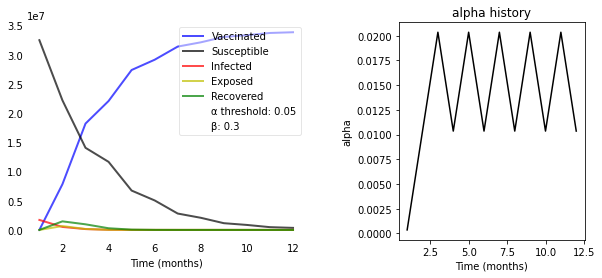

r_eff reward
alpha reward
alpha: 0.0204, S: 194115, E: 0, I: 0, Q: 0, R: 0, D: 0, V: 34023884
Episode 9: reward: 20.000, steps: 12
alpha reward
alpha: 0.0103, S: 22201318, E: 662965, I: 509263, Q: 1544081, R: 1467909, D: 0, V: 7832460
alpha reward
alpha: 0.0204, S: 14070122, E: 160340, I: 143269, Q: 668063, R: 959646, D: 0, V: 18216557
r_eff reward
alpha reward
alpha: 0.0103, S: 11664240, E: 21797, I: 20799, Q: 141282, R: 287109, D: 0, V: 22082770
r_eff reward
alpha reward
alpha: 0.0204, S: 6742383, E: 1592, I: 1756, Q: 19403, R: 54036, D: 0, V: 27398828
r_eff reward
alpha reward
alpha: 0.0103, S: 5050112, E: 68, I: 82, Q: 1769, R: 7114, D: 0, V: 29158851
r_eff reward
alpha reward
alpha: 0.0204, S: 2804564, E: 1, I: 2, Q: 125, R: 717, D: 0, V: 31412587
r_eff reward
alpha reward
alpha: 0.0103, S: 2077997, E: 0, I: 0, Q: 7, R: 60, D: 0, V: 32139934
r_eff reward
alpha reward
alpha: 0.0204, S: 1151760, E: 0, I: 0, Q: 0, R: 4, D: 0, V: 33066234
r_eff reward
alpha reward
alpha: 0.0103, S: 85

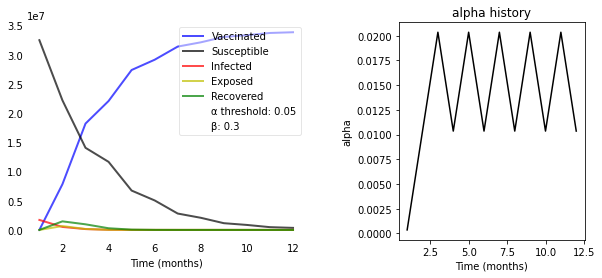

r_eff reward
alpha reward
alpha: 0.0204, S: 194115, E: 0, I: 0, Q: 0, R: 0, D: 0, V: 34023884
Episode 10: reward: 20.000, steps: 12
alpha reward
alpha: 0.0103, S: 22201318, E: 662965, I: 509263, Q: 1544081, R: 1467909, D: 0, V: 7832460
alpha reward
alpha: 0.0204, S: 14070122, E: 160340, I: 143269, Q: 668063, R: 959646, D: 0, V: 18216557
r_eff reward
alpha reward
alpha: 0.0103, S: 11664240, E: 21797, I: 20799, Q: 141282, R: 287109, D: 0, V: 22082770
r_eff reward
alpha reward
alpha: 0.0204, S: 6742383, E: 1592, I: 1756, Q: 19403, R: 54036, D: 0, V: 27398828
r_eff reward
alpha reward
alpha: 0.0103, S: 5050112, E: 68, I: 82, Q: 1769, R: 7114, D: 0, V: 29158851
r_eff reward
alpha reward
alpha: 0.0204, S: 2804564, E: 1, I: 2, Q: 125, R: 717, D: 0, V: 31412587
r_eff reward
alpha reward
alpha: 0.0103, S: 2077997, E: 0, I: 0, Q: 7, R: 60, D: 0, V: 32139934
r_eff reward
alpha reward
alpha: 0.0204, S: 1151760, E: 0, I: 0, Q: 0, R: 4, D: 0, V: 33066234
r_eff reward
alpha reward
alpha: 0.0103, S: 8

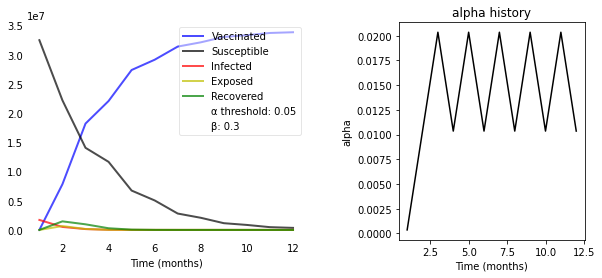

r_eff reward
alpha reward
alpha: 0.0204, S: 194115, E: 0, I: 0, Q: 0, R: 0, D: 0, V: 34023884
Episode 11: reward: 20.000, steps: 12
alpha reward
alpha: 0.0103, S: 22201318, E: 662965, I: 509263, Q: 1544081, R: 1467909, D: 0, V: 7832460
alpha reward
alpha: 0.0204, S: 14070122, E: 160340, I: 143269, Q: 668063, R: 959646, D: 0, V: 18216557
r_eff reward
alpha reward
alpha: 0.0103, S: 11664240, E: 21797, I: 20799, Q: 141282, R: 287109, D: 0, V: 22082770
r_eff reward
alpha reward
alpha: 0.0204, S: 6742383, E: 1592, I: 1756, Q: 19403, R: 54036, D: 0, V: 27398828
r_eff reward
alpha reward
alpha: 0.0103, S: 5050112, E: 68, I: 82, Q: 1769, R: 7114, D: 0, V: 29158851
r_eff reward
alpha reward
alpha: 0.0204, S: 2804564, E: 1, I: 2, Q: 125, R: 717, D: 0, V: 31412587
r_eff reward
alpha reward
alpha: 0.0103, S: 2077997, E: 0, I: 0, Q: 7, R: 60, D: 0, V: 32139934
r_eff reward
alpha reward
alpha: 0.0204, S: 1151760, E: 0, I: 0, Q: 0, R: 4, D: 0, V: 33066234
r_eff reward
alpha reward
alpha: 0.0103, S: 8

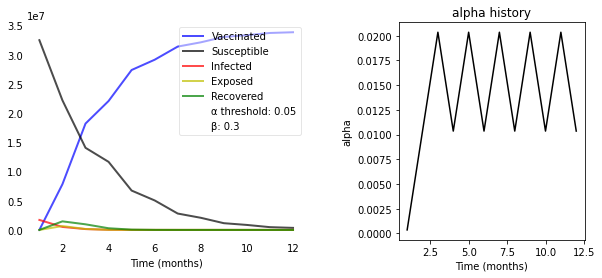

r_eff reward
alpha reward
alpha: 0.0204, S: 194115, E: 0, I: 0, Q: 0, R: 0, D: 0, V: 34023884
Episode 12: reward: 20.000, steps: 12
alpha reward
alpha: 0.0103, S: 22201318, E: 662965, I: 509263, Q: 1544081, R: 1467909, D: 0, V: 7832460
alpha reward
alpha: 0.0204, S: 14070122, E: 160340, I: 143269, Q: 668063, R: 959646, D: 0, V: 18216557
r_eff reward
alpha reward
alpha: 0.0103, S: 11664240, E: 21797, I: 20799, Q: 141282, R: 287109, D: 0, V: 22082770
r_eff reward
alpha reward
alpha: 0.0204, S: 6742383, E: 1592, I: 1756, Q: 19403, R: 54036, D: 0, V: 27398828
r_eff reward
alpha reward
alpha: 0.0103, S: 5050112, E: 68, I: 82, Q: 1769, R: 7114, D: 0, V: 29158851
r_eff reward
alpha reward
alpha: 0.0204, S: 2804564, E: 1, I: 2, Q: 125, R: 717, D: 0, V: 31412587
r_eff reward
alpha reward
alpha: 0.0103, S: 2077997, E: 0, I: 0, Q: 7, R: 60, D: 0, V: 32139934
r_eff reward
alpha reward
alpha: 0.0204, S: 1151760, E: 0, I: 0, Q: 0, R: 4, D: 0, V: 33066234
r_eff reward
alpha reward
alpha: 0.0103, S: 8

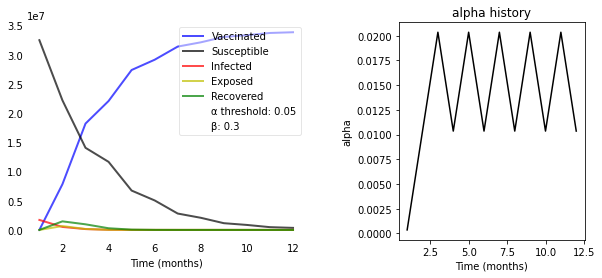

r_eff reward
alpha reward
alpha: 0.0204, S: 194115, E: 0, I: 0, Q: 0, R: 0, D: 0, V: 34023884
Episode 13: reward: 20.000, steps: 12
alpha reward
alpha: 0.0103, S: 22201318, E: 662965, I: 509263, Q: 1544081, R: 1467909, D: 0, V: 7832460
alpha reward
alpha: 0.0204, S: 14070122, E: 160340, I: 143269, Q: 668063, R: 959646, D: 0, V: 18216557
r_eff reward
alpha reward
alpha: 0.0103, S: 11664240, E: 21797, I: 20799, Q: 141282, R: 287109, D: 0, V: 22082770
r_eff reward
alpha reward
alpha: 0.0204, S: 6742383, E: 1592, I: 1756, Q: 19403, R: 54036, D: 0, V: 27398828
r_eff reward
alpha reward
alpha: 0.0103, S: 5050112, E: 68, I: 82, Q: 1769, R: 7114, D: 0, V: 29158851
r_eff reward
alpha reward
alpha: 0.0204, S: 2804564, E: 1, I: 2, Q: 125, R: 717, D: 0, V: 31412587
r_eff reward
alpha reward
alpha: 0.0103, S: 2077997, E: 0, I: 0, Q: 7, R: 60, D: 0, V: 32139934
r_eff reward
alpha reward
alpha: 0.0204, S: 1151760, E: 0, I: 0, Q: 0, R: 4, D: 0, V: 33066234
r_eff reward
alpha reward
alpha: 0.0103, S: 8

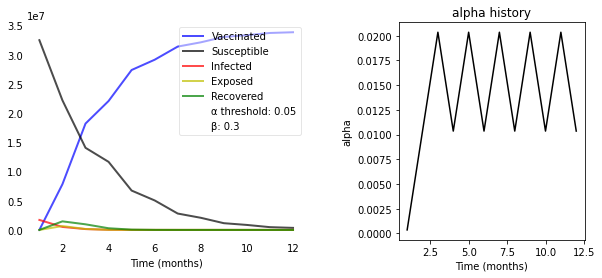

r_eff reward
alpha reward
alpha: 0.0204, S: 194115, E: 0, I: 0, Q: 0, R: 0, D: 0, V: 34023884
Episode 14: reward: 20.000, steps: 12
alpha reward
alpha: 0.0103, S: 22201318, E: 662965, I: 509263, Q: 1544081, R: 1467909, D: 0, V: 7832460
alpha reward
alpha: 0.0204, S: 14070122, E: 160340, I: 143269, Q: 668063, R: 959646, D: 0, V: 18216557
r_eff reward
alpha reward
alpha: 0.0103, S: 11664240, E: 21797, I: 20799, Q: 141282, R: 287109, D: 0, V: 22082770
r_eff reward
alpha reward
alpha: 0.0204, S: 6742383, E: 1592, I: 1756, Q: 19403, R: 54036, D: 0, V: 27398828
r_eff reward
alpha reward
alpha: 0.0103, S: 5050112, E: 68, I: 82, Q: 1769, R: 7114, D: 0, V: 29158851
r_eff reward
alpha reward
alpha: 0.0204, S: 2804564, E: 1, I: 2, Q: 125, R: 717, D: 0, V: 31412587
r_eff reward
alpha reward
alpha: 0.0103, S: 2077997, E: 0, I: 0, Q: 7, R: 60, D: 0, V: 32139934
r_eff reward
alpha reward
alpha: 0.0204, S: 1151760, E: 0, I: 0, Q: 0, R: 4, D: 0, V: 33066234
r_eff reward
alpha reward
alpha: 0.0103, S: 8

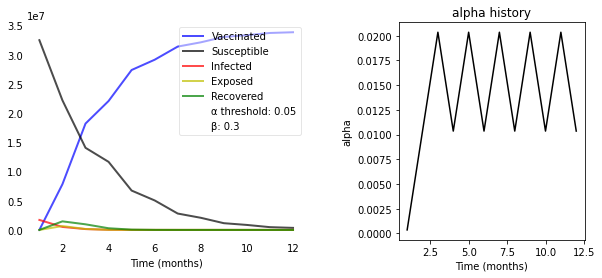

r_eff reward
alpha reward
alpha: 0.0204, S: 194115, E: 0, I: 0, Q: 0, R: 0, D: 0, V: 34023884
Episode 15: reward: 20.000, steps: 12
alpha reward
alpha: 0.0103, S: 22201318, E: 662965, I: 509263, Q: 1544081, R: 1467909, D: 0, V: 7832460
alpha reward
alpha: 0.0204, S: 14070122, E: 160340, I: 143269, Q: 668063, R: 959646, D: 0, V: 18216557
r_eff reward
alpha reward
alpha: 0.0103, S: 11664240, E: 21797, I: 20799, Q: 141282, R: 287109, D: 0, V: 22082770
r_eff reward
alpha reward
alpha: 0.0204, S: 6742383, E: 1592, I: 1756, Q: 19403, R: 54036, D: 0, V: 27398828
r_eff reward
alpha reward
alpha: 0.0103, S: 5050112, E: 68, I: 82, Q: 1769, R: 7114, D: 0, V: 29158851
r_eff reward
alpha reward
alpha: 0.0204, S: 2804564, E: 1, I: 2, Q: 125, R: 717, D: 0, V: 31412587
r_eff reward
alpha reward
alpha: 0.0103, S: 2077997, E: 0, I: 0, Q: 7, R: 60, D: 0, V: 32139934
r_eff reward
alpha reward
alpha: 0.0204, S: 1151760, E: 0, I: 0, Q: 0, R: 4, D: 0, V: 33066234
r_eff reward
alpha reward
alpha: 0.0103, S: 8

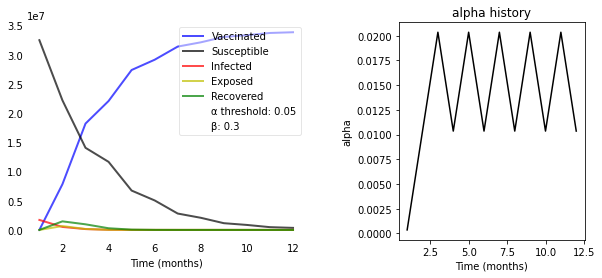

r_eff reward
alpha reward
alpha: 0.0204, S: 194115, E: 0, I: 0, Q: 0, R: 0, D: 0, V: 34023884
Episode 16: reward: 20.000, steps: 12
alpha reward
alpha: 0.0103, S: 22201318, E: 662965, I: 509263, Q: 1544081, R: 1467909, D: 0, V: 7832460
alpha reward
alpha: 0.0204, S: 14070122, E: 160340, I: 143269, Q: 668063, R: 959646, D: 0, V: 18216557
r_eff reward
alpha reward
alpha: 0.0103, S: 11664240, E: 21797, I: 20799, Q: 141282, R: 287109, D: 0, V: 22082770
r_eff reward
alpha reward
alpha: 0.0204, S: 6742383, E: 1592, I: 1756, Q: 19403, R: 54036, D: 0, V: 27398828
r_eff reward
alpha reward
alpha: 0.0103, S: 5050112, E: 68, I: 82, Q: 1769, R: 7114, D: 0, V: 29158851
r_eff reward
alpha reward
alpha: 0.0204, S: 2804564, E: 1, I: 2, Q: 125, R: 717, D: 0, V: 31412587
r_eff reward
alpha reward
alpha: 0.0103, S: 2077997, E: 0, I: 0, Q: 7, R: 60, D: 0, V: 32139934
r_eff reward
alpha reward
alpha: 0.0204, S: 1151760, E: 0, I: 0, Q: 0, R: 4, D: 0, V: 33066234
r_eff reward
alpha reward
alpha: 0.0103, S: 8

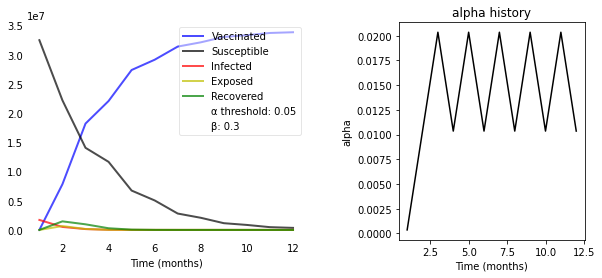

r_eff reward
alpha reward
alpha: 0.0204, S: 194115, E: 0, I: 0, Q: 0, R: 0, D: 0, V: 34023884
Episode 17: reward: 20.000, steps: 12
alpha reward
alpha: 0.0103, S: 22201318, E: 662965, I: 509263, Q: 1544081, R: 1467909, D: 0, V: 7832460
alpha reward
alpha: 0.0204, S: 14070122, E: 160340, I: 143269, Q: 668063, R: 959646, D: 0, V: 18216557
r_eff reward
alpha reward
alpha: 0.0103, S: 11664240, E: 21797, I: 20799, Q: 141282, R: 287109, D: 0, V: 22082770
r_eff reward
alpha reward
alpha: 0.0204, S: 6742383, E: 1592, I: 1756, Q: 19403, R: 54036, D: 0, V: 27398828
r_eff reward
alpha reward
alpha: 0.0103, S: 5050112, E: 68, I: 82, Q: 1769, R: 7114, D: 0, V: 29158851
r_eff reward
alpha reward
alpha: 0.0204, S: 2804564, E: 1, I: 2, Q: 125, R: 717, D: 0, V: 31412587
r_eff reward
alpha reward
alpha: 0.0103, S: 2077997, E: 0, I: 0, Q: 7, R: 60, D: 0, V: 32139934
r_eff reward
alpha reward
alpha: 0.0204, S: 1151760, E: 0, I: 0, Q: 0, R: 4, D: 0, V: 33066234
r_eff reward
alpha reward
alpha: 0.0103, S: 8

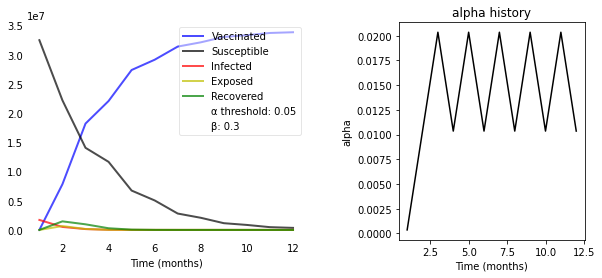

r_eff reward
alpha reward
alpha: 0.0204, S: 194115, E: 0, I: 0, Q: 0, R: 0, D: 0, V: 34023884
Episode 18: reward: 20.000, steps: 12
alpha reward
alpha: 0.0103, S: 22201318, E: 662965, I: 509263, Q: 1544081, R: 1467909, D: 0, V: 7832460
alpha reward
alpha: 0.0204, S: 14070122, E: 160340, I: 143269, Q: 668063, R: 959646, D: 0, V: 18216557
r_eff reward
alpha reward
alpha: 0.0103, S: 11664240, E: 21797, I: 20799, Q: 141282, R: 287109, D: 0, V: 22082770
r_eff reward
alpha reward
alpha: 0.0204, S: 6742383, E: 1592, I: 1756, Q: 19403, R: 54036, D: 0, V: 27398828
r_eff reward
alpha reward
alpha: 0.0103, S: 5050112, E: 68, I: 82, Q: 1769, R: 7114, D: 0, V: 29158851
r_eff reward
alpha reward
alpha: 0.0204, S: 2804564, E: 1, I: 2, Q: 125, R: 717, D: 0, V: 31412587
r_eff reward
alpha reward
alpha: 0.0103, S: 2077997, E: 0, I: 0, Q: 7, R: 60, D: 0, V: 32139934
r_eff reward
alpha reward
alpha: 0.0204, S: 1151760, E: 0, I: 0, Q: 0, R: 4, D: 0, V: 33066234
r_eff reward
alpha reward
alpha: 0.0103, S: 8

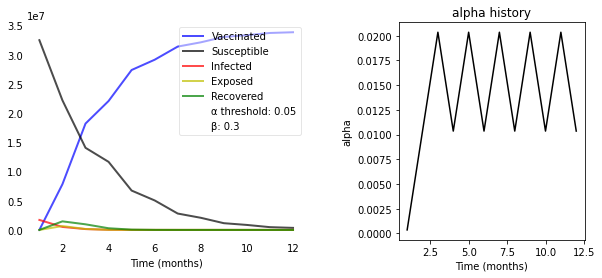

r_eff reward
alpha reward
alpha: 0.0204, S: 194115, E: 0, I: 0, Q: 0, R: 0, D: 0, V: 34023884
Episode 19: reward: 20.000, steps: 12
alpha reward
alpha: 0.0103, S: 22201318, E: 662965, I: 509263, Q: 1544081, R: 1467909, D: 0, V: 7832460
alpha reward
alpha: 0.0204, S: 14070122, E: 160340, I: 143269, Q: 668063, R: 959646, D: 0, V: 18216557
r_eff reward
alpha reward
alpha: 0.0103, S: 11664240, E: 21797, I: 20799, Q: 141282, R: 287109, D: 0, V: 22082770
r_eff reward
alpha reward
alpha: 0.0204, S: 6742383, E: 1592, I: 1756, Q: 19403, R: 54036, D: 0, V: 27398828
r_eff reward
alpha reward
alpha: 0.0103, S: 5050112, E: 68, I: 82, Q: 1769, R: 7114, D: 0, V: 29158851
r_eff reward
alpha reward
alpha: 0.0204, S: 2804564, E: 1, I: 2, Q: 125, R: 717, D: 0, V: 31412587
r_eff reward
alpha reward
alpha: 0.0103, S: 2077997, E: 0, I: 0, Q: 7, R: 60, D: 0, V: 32139934
r_eff reward
alpha reward
alpha: 0.0204, S: 1151760, E: 0, I: 0, Q: 0, R: 4, D: 0, V: 33066234
r_eff reward
alpha reward
alpha: 0.0103, S: 8

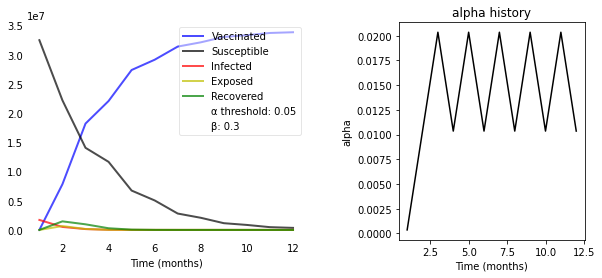

r_eff reward
alpha reward
alpha: 0.0204, S: 194115, E: 0, I: 0, Q: 0, R: 0, D: 0, V: 34023884
Episode 20: reward: 20.000, steps: 12


In [23]:
_ = dqn.test(env, nb_episodes=20, visualize=True)

In [24]:
dqn.save_weights('SEIQRDV_dqn_weights.h5f', overwrite=True)

In [25]:
# changing beta
# change alpha-threshold (0.1, 0.2, 0.3, 0.4, 0.5)

# highlight the novelty